# Transcriptome PCA: Do Dysbiotic Samples Cluster? (Recalled Genera)

Updated version of `Local_analysis/Followup_analyses_after_Luke_talk/Core_species_and_dysbiosis/transcriptome_pca_do_dysbiotic_samples_cluster.ipynb`.

Changes from the original:
- **Dysbiosis calls:** read from `dysbiosis_calls_recalled_genera.csv`, written by `dysbiosis_calls_and_defense_score_recalled_genera.ipynb` (rare genera < 10% seasonal prevalence; the abundance threshold is set there). Run that notebook first.
- **Microbiome PCA:** the cells using the microbiome ordination are commented out; Luke is redoing it for the recalled genera.
- Everything else (transcriptome set, outlier removal, transcriptome PCA, centroid distances, PERMDISP, transcriptome regressions) is as in the original.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import scipy.stats as stats

In [2]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
raw_transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_for_norm.csv",
    index_col=0,
)

## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### For remaining duplicated sampIDs, drop the transcriptome with fewer total reads
double_duplicates = (
    trimmed_metadata.loc[trimmed_metadata.duplicated(subset="sampID", keep=False)]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_raw_transcriptome = raw_transcriptome.loc[trimmed_metadata.index]
print("Transcriptomes after removing replicates:", len(trimmed_metadata))

Transcriptomes after removing replicates: 432


In [3]:
# Dysbiosis calls from dysbiosis_calls_and_defense_score_recalled_genera.ipynb
# (rare genera = < 10% prevalence in seasonal plant samples; the abundance
# threshold is set in that notebook)
dysbiosis_calls = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/dysbiosis_calls_recalled_genera.csv",
    index_col="sampID",
)
rare_genera_abundance_threshold = dysbiosis_calls["rare_genera_abundance_threshold"].iloc[0]
print(f"Rare genera abundance threshold: {rare_genera_abundance_threshold}%")

trimmed_metadata["rare_genera_total_abund"] = trimmed_metadata["sampID"].map(
    dysbiosis_calls["rare_genera_total_abund"]
)
missing_microbiome = trimmed_metadata["rare_genera_total_abund"].isna()
print(
    f"Transcriptomes without a microbiome profile: {missing_microbiome.sum()} "
    "(counted as not dysbiotic, as in the original)"
)
trimmed_metadata["rare_genera_total_abund"] = trimmed_metadata[
    "rare_genera_total_abund"
].fillna(0.0)

Rare genera abundance threshold: 1.0%
Transcriptomes without a microbiome profile: 4 (counted as not dysbiotic, as in the original)


In [4]:
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=0)
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=1)

In [5]:
### Remove outlier identifed
trimmed_transcriptome = trimmed_transcriptome.drop(index="A2534491401_n01_LICRNA05_A10")
trimmed_metadata = trimmed_metadata.drop(index="A2534491401_n01_LICRNA05_A10")
trimmed_transcriptome = trimmed_transcriptome.drop(index="A2534491401_n01_LICRNA05_A09")
trimmed_metadata = trimmed_metadata.drop(index="A2534491401_n01_LICRNA05_A09")

In [6]:
pca = sklearn.decomposition.PCA(n_components=5).fit_transform(trimmed_transcriptome)
pca

array([[-110436.79525524,  -58882.28811264,   -1952.063329  ,
          21362.38993932,   -3469.06839245],
       [-131473.97496125,  -16522.9744646 ,  -12456.79260346,
          18068.42456746,   -7280.05127809],
       [-135692.25380761,  -61353.02663578,  -17848.45515268,
           4084.83227876,   -9289.10279398],
       ...,
       [  13538.92829182,  -49037.21423427,    1652.17227473,
          -3845.06556531,   -1791.41676601],
       [-110856.83969965,  -21814.37171526,   13263.54981151,
         -10585.3007462 ,   20898.62584996],
       [ -58911.00283244,   24083.02032912,   24694.15583667,
          -4256.96973179,    9208.23549579]], shape=(430, 5))

In [7]:
trimmed_metadata["Dysbiosis Status"] = "Normal"
trimmed_metadata.loc[
    trimmed_metadata["rare_genera_total_abund"] > rare_genera_abundance_threshold,
    "Dysbiosis Status",
] = "Dysbiotic"
trimmed_metadata["Dysbiosis Status"].value_counts()

Dysbiosis Status
Normal       373
Dysbiotic     57
Name: count, dtype: int64

(array([-150000., -100000.,  -50000.,       0.,   50000.,  100000.,
         150000.]),
 [Text(0, -150000.0, '−150000'),
  Text(0, -100000.0, '−100000'),
  Text(0, -50000.0, '−50000'),
  Text(0, 0.0, '0'),
  Text(0, 50000.0, '50000'),
  Text(0, 100000.0, '100000'),
  Text(0, 150000.0, '150000')])

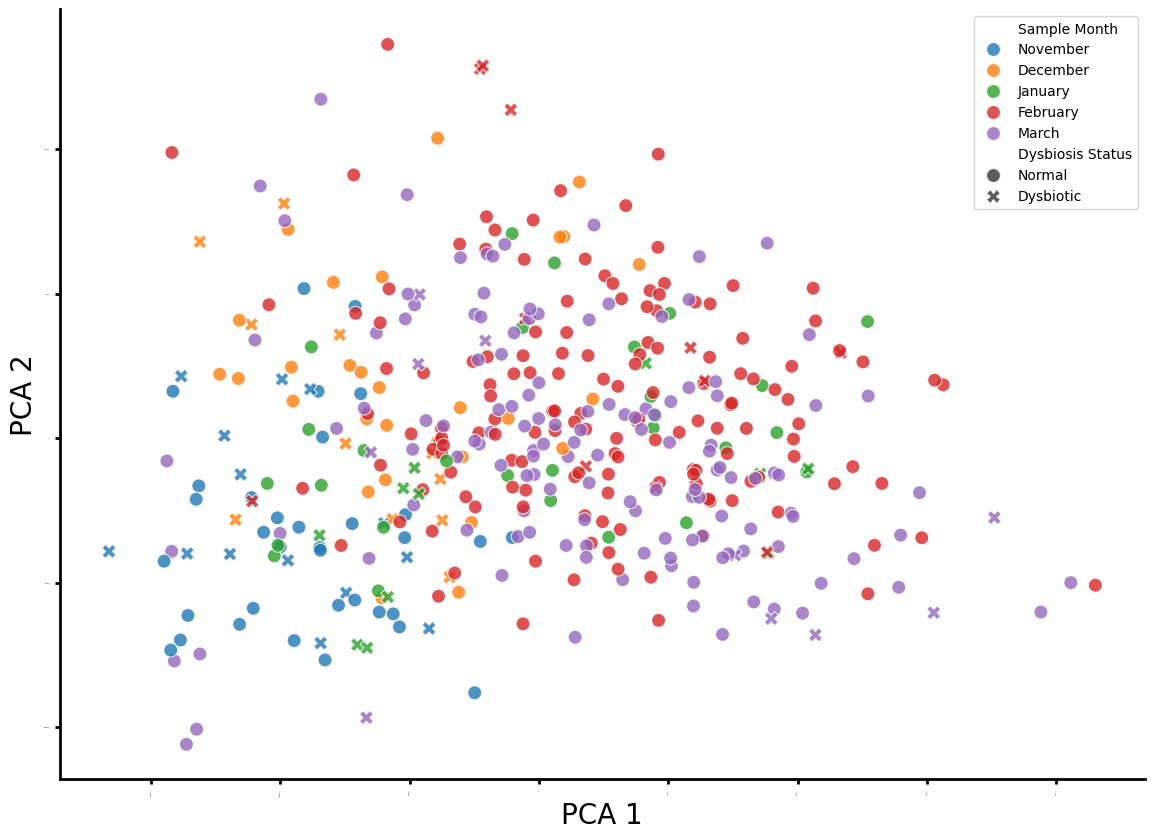

In [8]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=pca[:, 0],
    y=pca[:, 1],
    style=trimmed_metadata["Dysbiosis Status"],
    hue=trimmed_metadata["Sample Month"],
    s=100,
    alpha=0.8,
)
plt.xlabel("PCA 1", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

# plt.ylim(0,10)

(array([-150000., -100000.,  -50000.,       0.,   50000.,  100000.,
         150000.]),
 [Text(0, -150000.0, '−150000'),
  Text(0, -100000.0, '−100000'),
  Text(0, -50000.0, '−50000'),
  Text(0, 0.0, '0'),
  Text(0, 50000.0, '50000'),
  Text(0, 100000.0, '100000'),
  Text(0, 150000.0, '150000')])

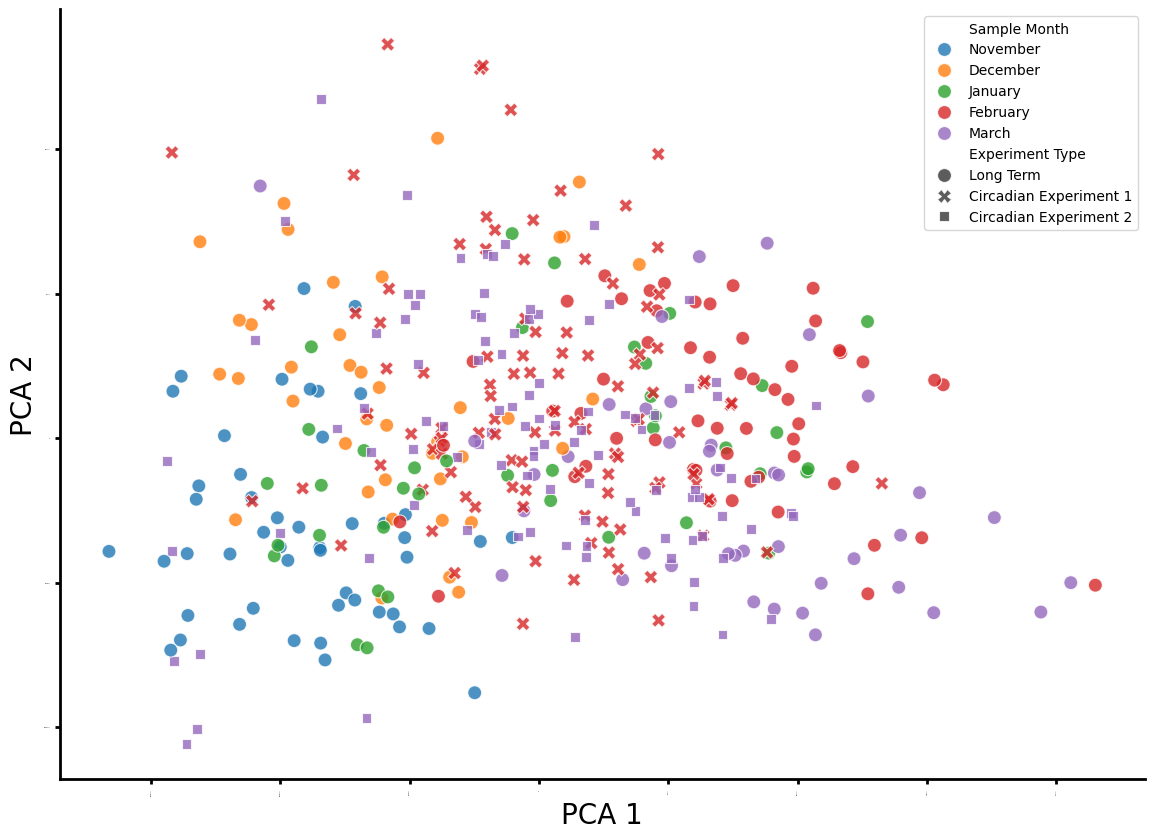

In [9]:
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    x=pca[:, 0],
    y=pca[:, 1],
    style=trimmed_metadata["Experiment Type"],
    hue=trimmed_metadata["Sample Month"],
    s=100,
    alpha=0.8,
)
plt.xlabel("PCA 1", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

# plt.ylim(0,10)

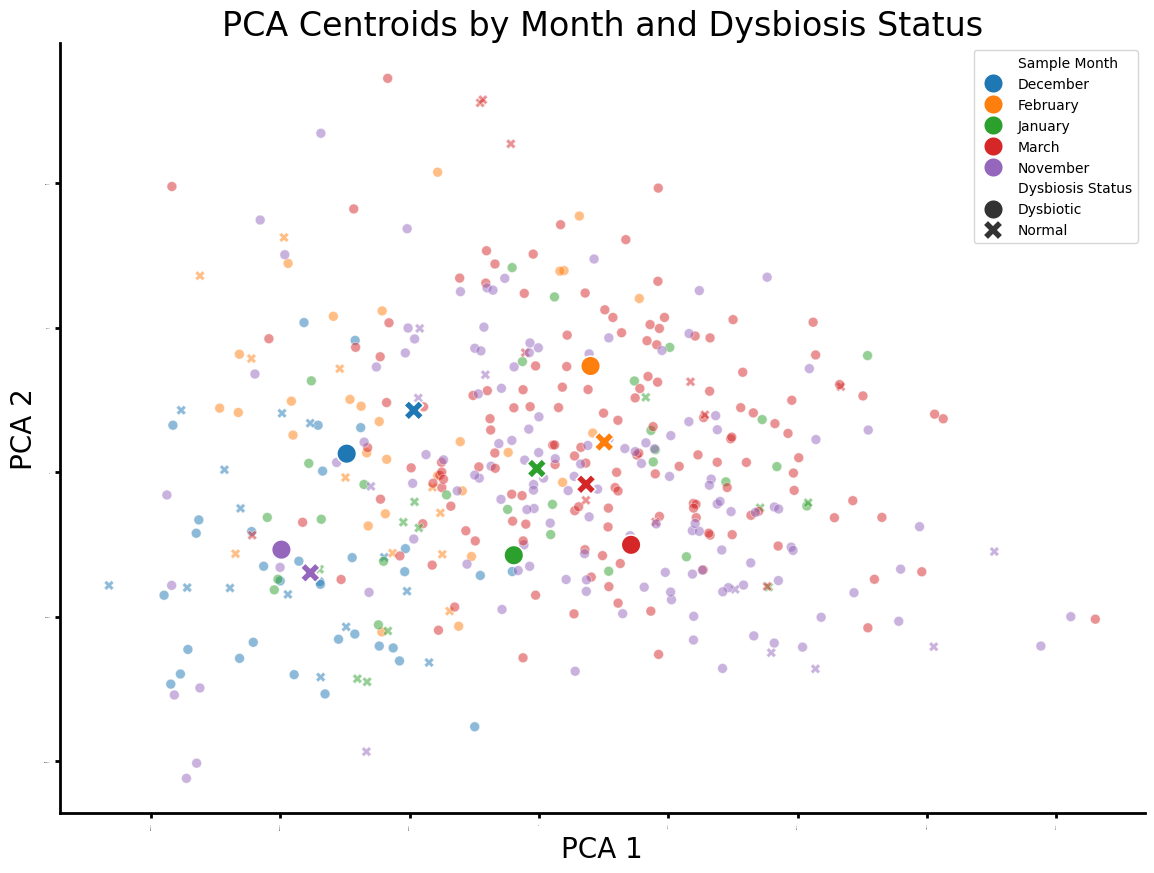

In [10]:
pca_df = pd.DataFrame(
    pca[:, :2], columns=["PCA 1", "PCA 2"], index=trimmed_metadata.index
)
pca_df["Sample Month"] = trimmed_metadata["Sample Month"]
pca_df["Dysbiosis Status"] = trimmed_metadata["Dysbiosis Status"]

centroids = pca_df.groupby(["Sample Month", "Dysbiosis Status"]).mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor("white")

# Plot background points
sns.scatterplot(
    x=pca[:, 0],
    y=pca[:, 1],
    style=trimmed_metadata["Dysbiosis Status"],
    hue=trimmed_metadata["Sample Month"],
    s=50,
    alpha=0.5,
    ax=ax,
    legend=False,
)

# Plot centroids
sns.scatterplot(
    data=centroids,
    x="PCA 1",
    y="PCA 2",
    style="Dysbiosis Status",
    hue="Sample Month",
    s=200,
    alpha=1.0,
    ax=ax,
)

plt.xlabel("PCA 1", fontsize=20)
plt.ylabel("PCA 2", fontsize=20)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.legend(loc="upper right")
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
plt.title("PCA Centroids by Month and Dysbiosis Status", fontsize=24)
plt.show()

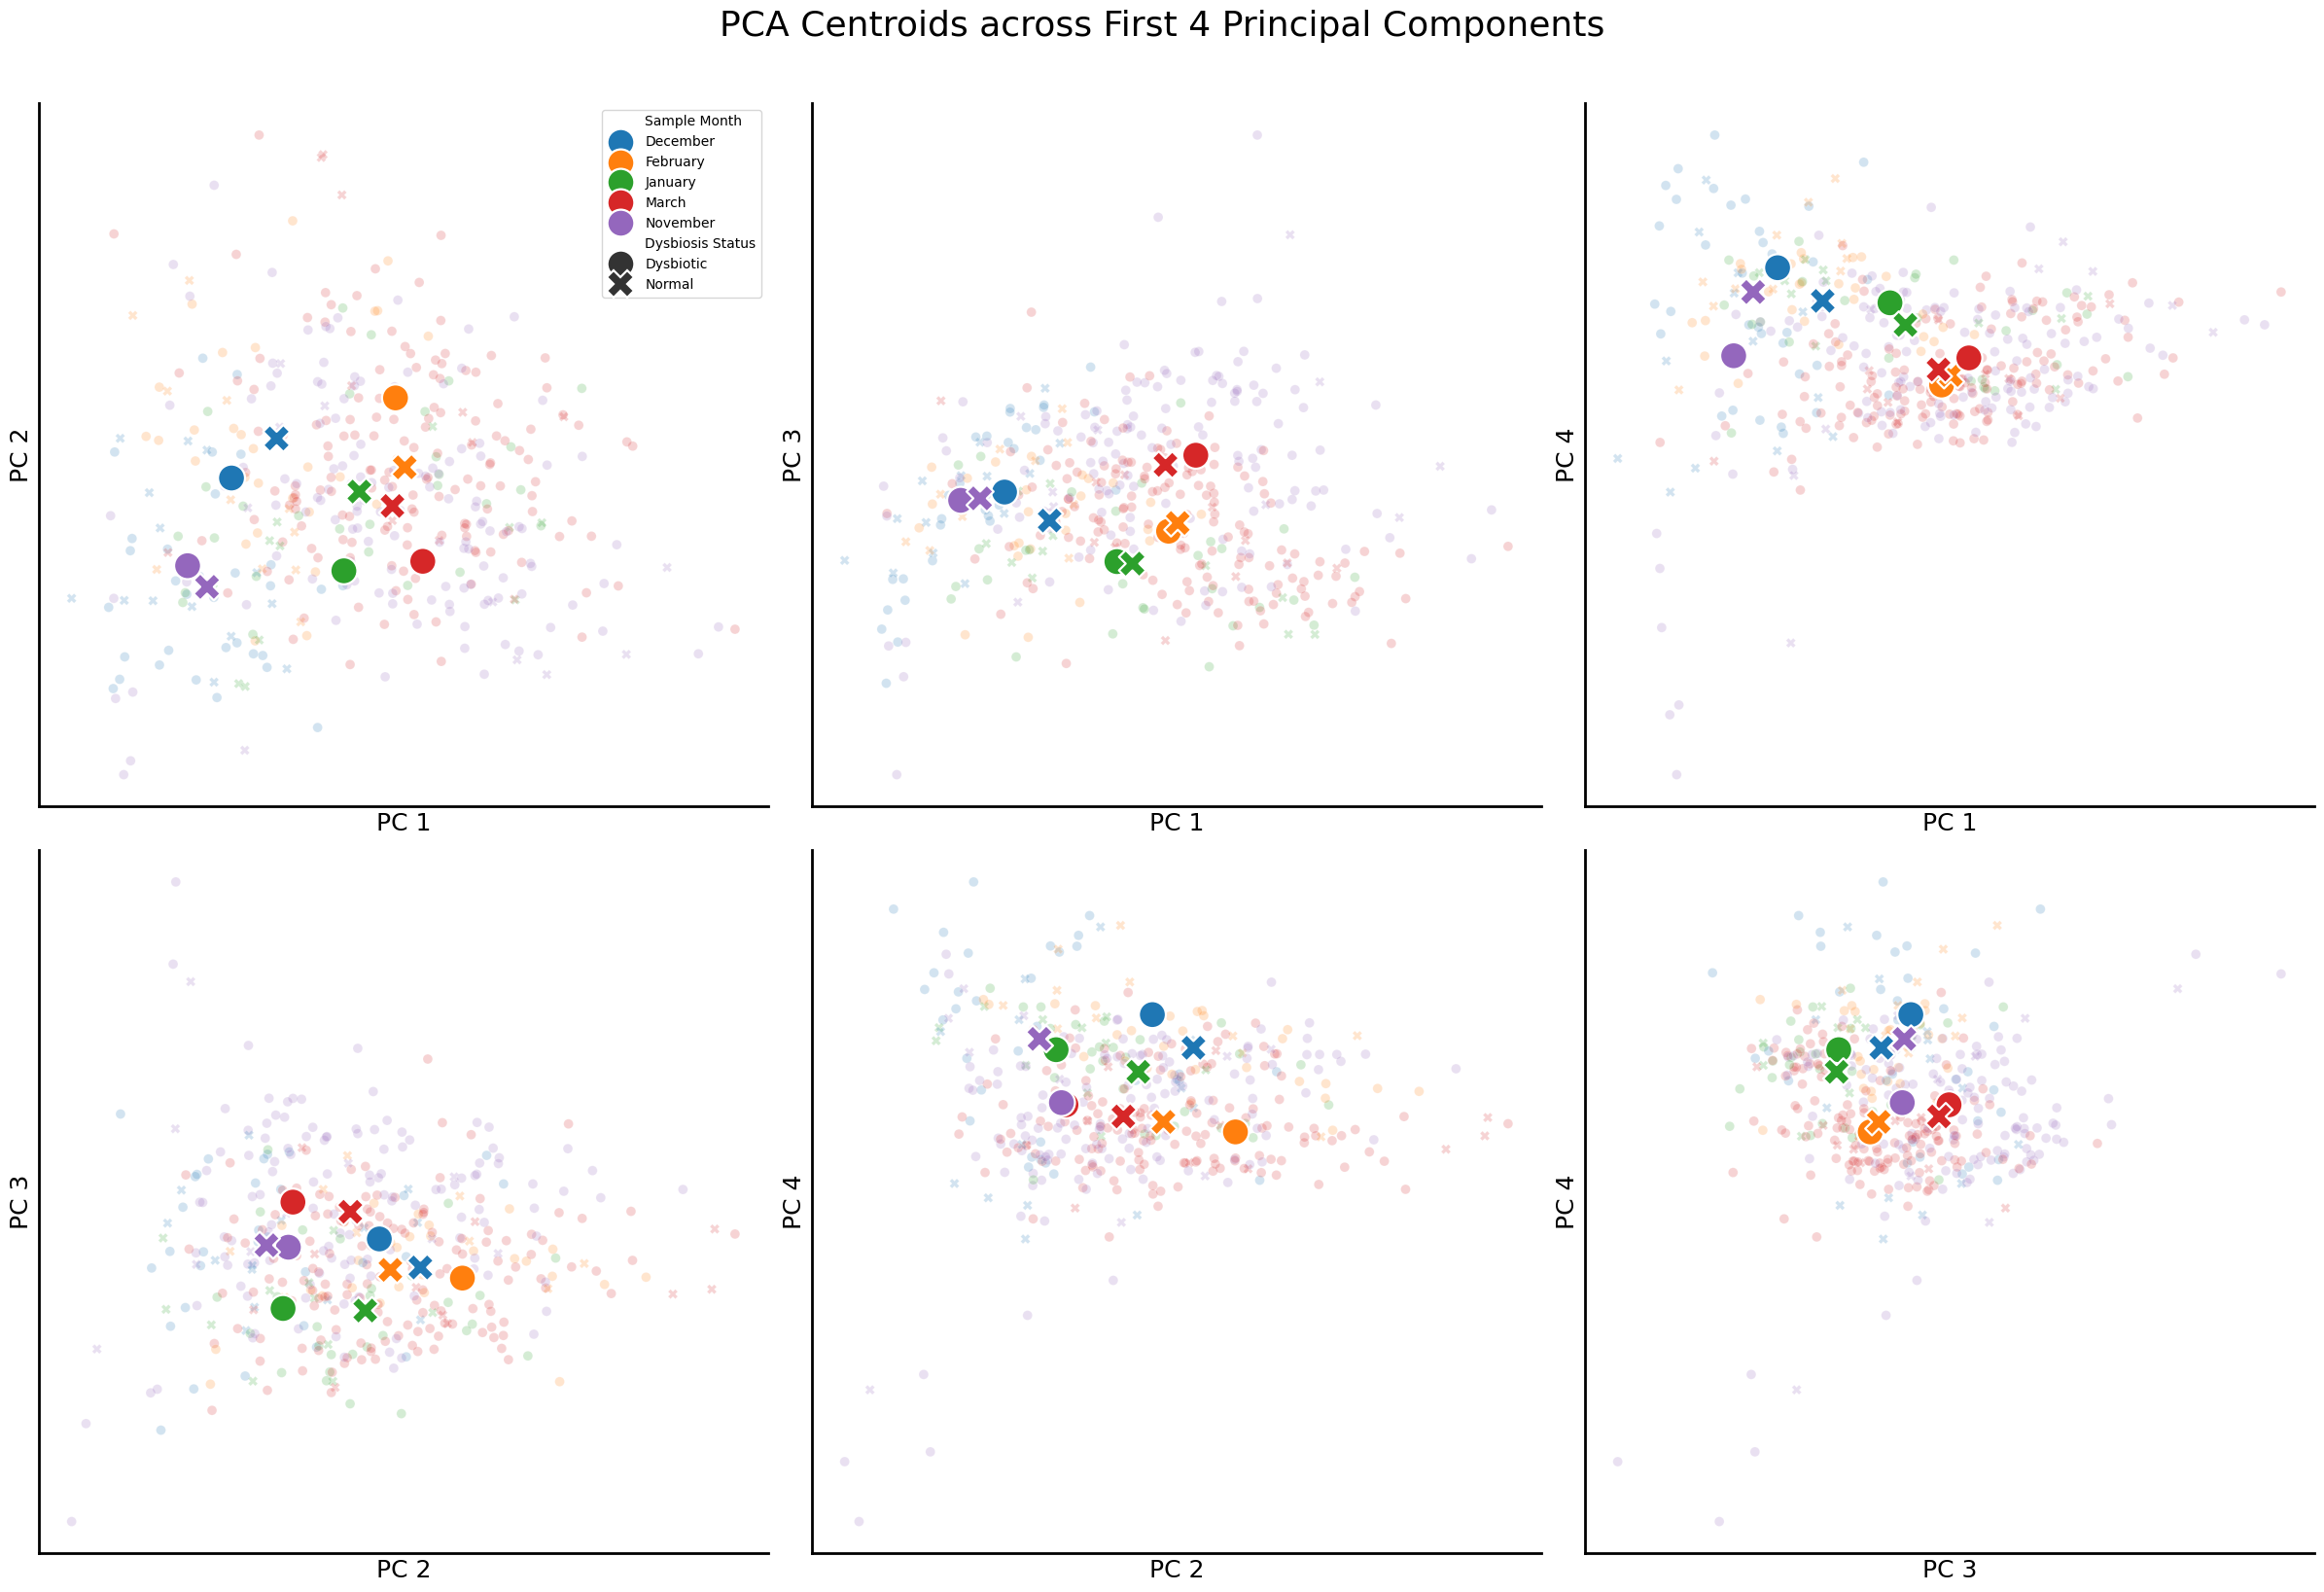

In [11]:
pca_df_multi = pd.DataFrame(
    pca[:, :4], columns=["PC 1", "PC 2", "PC 3", "PC 4"], index=trimmed_metadata.index
)
pca_df_multi["Sample Month"] = trimmed_metadata["Sample Month"]
pca_df_multi["Dysbiosis Status"] = trimmed_metadata["Dysbiosis Status"]

centroids_multi = (
    pca_df_multi.groupby(["Sample Month", "Dysbiosis Status"]).mean().reset_index()
)

pairs = [(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.patch.set_facecolor("white")
axes = axes.flatten()

for i, (pc_x, pc_y) in enumerate(pairs):
    ax = axes[i]
    col_x = f"PC {pc_x}"
    col_y = f"PC {pc_y}"

    # Plot background points
    sns.scatterplot(
        data=pca_df_multi,
        x=col_x,
        y=col_y,
        style="Dysbiosis Status",
        hue="Sample Month",
        s=50,
        alpha=0.2,
        ax=ax,
        legend=False,
    )

    # Plot centroids
    sns.scatterplot(
        data=centroids_multi,
        x=col_x,
        y=col_y,
        style="Dysbiosis Status",
        hue="Sample Month",
        s=400,
        alpha=1.0,
        ax=ax,
        legend=(i == 0),  # Only add legend to the first subplot to prevent clutter
    )

    ax.set_xlabel(col_x, fontsize=18)
    ax.set_ylabel(col_y, fontsize=18)
    sns.despine(ax=ax)
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", width=2)
    ax.set_xticks([])  # Remove tick labels for a cleaner look
    ax.set_yticks([])

plt.suptitle("PCA Centroids across First 4 Principal Components", fontsize=26, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
import plotly.express as px

# Create a dataframe for interactive plotting, taking useful metadata for hover
interactive_df = pca_df.copy()
interactive_df["filename"] = interactive_df.index
interactive_df["sampID"] = trimmed_metadata["sampID"]
interactive_df["plate.pos"] = trimmed_metadata["plate.pos"]
interactive_df["Experiment Type"] = trimmed_metadata["Experiment Type"]

# Plot using plotly
fig = px.scatter(
    interactive_df,
    x="PCA 1",
    y="PCA 2",
    color="Sample Month",
    symbol="Dysbiosis Status",
    hover_data=["filename", "sampID", "plate.pos", "Experiment Type"],
    title="Interactive PCA 1 vs PCA 2",
    width=1000,
    height=800,
)

fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.show()

In [13]:
# Create an interactive plot for PC 2 vs PC 3
interactive_df_23 = pca_df_multi.copy()
interactive_df_23["filename"] = interactive_df_23.index
interactive_df_23["sampID"] = trimmed_metadata["sampID"]
interactive_df_23["plate.pos"] = trimmed_metadata["plate.pos"]
interactive_df_23["Experiment Type"] = trimmed_metadata["Experiment Type"]

fig2 = px.scatter(
    interactive_df_23,
    x="PC 2",
    y="PC 3",
    color="Sample Month",
    symbol="Dysbiosis Status",
    hover_data=["filename", "sampID", "plate.pos", "Experiment Type"],
    title="Interactive PC 2 vs PC 3",
    width=1000,
    height=800,
)

fig2.update_traces(marker=dict(size=8, opacity=0.8))
fig2.show()

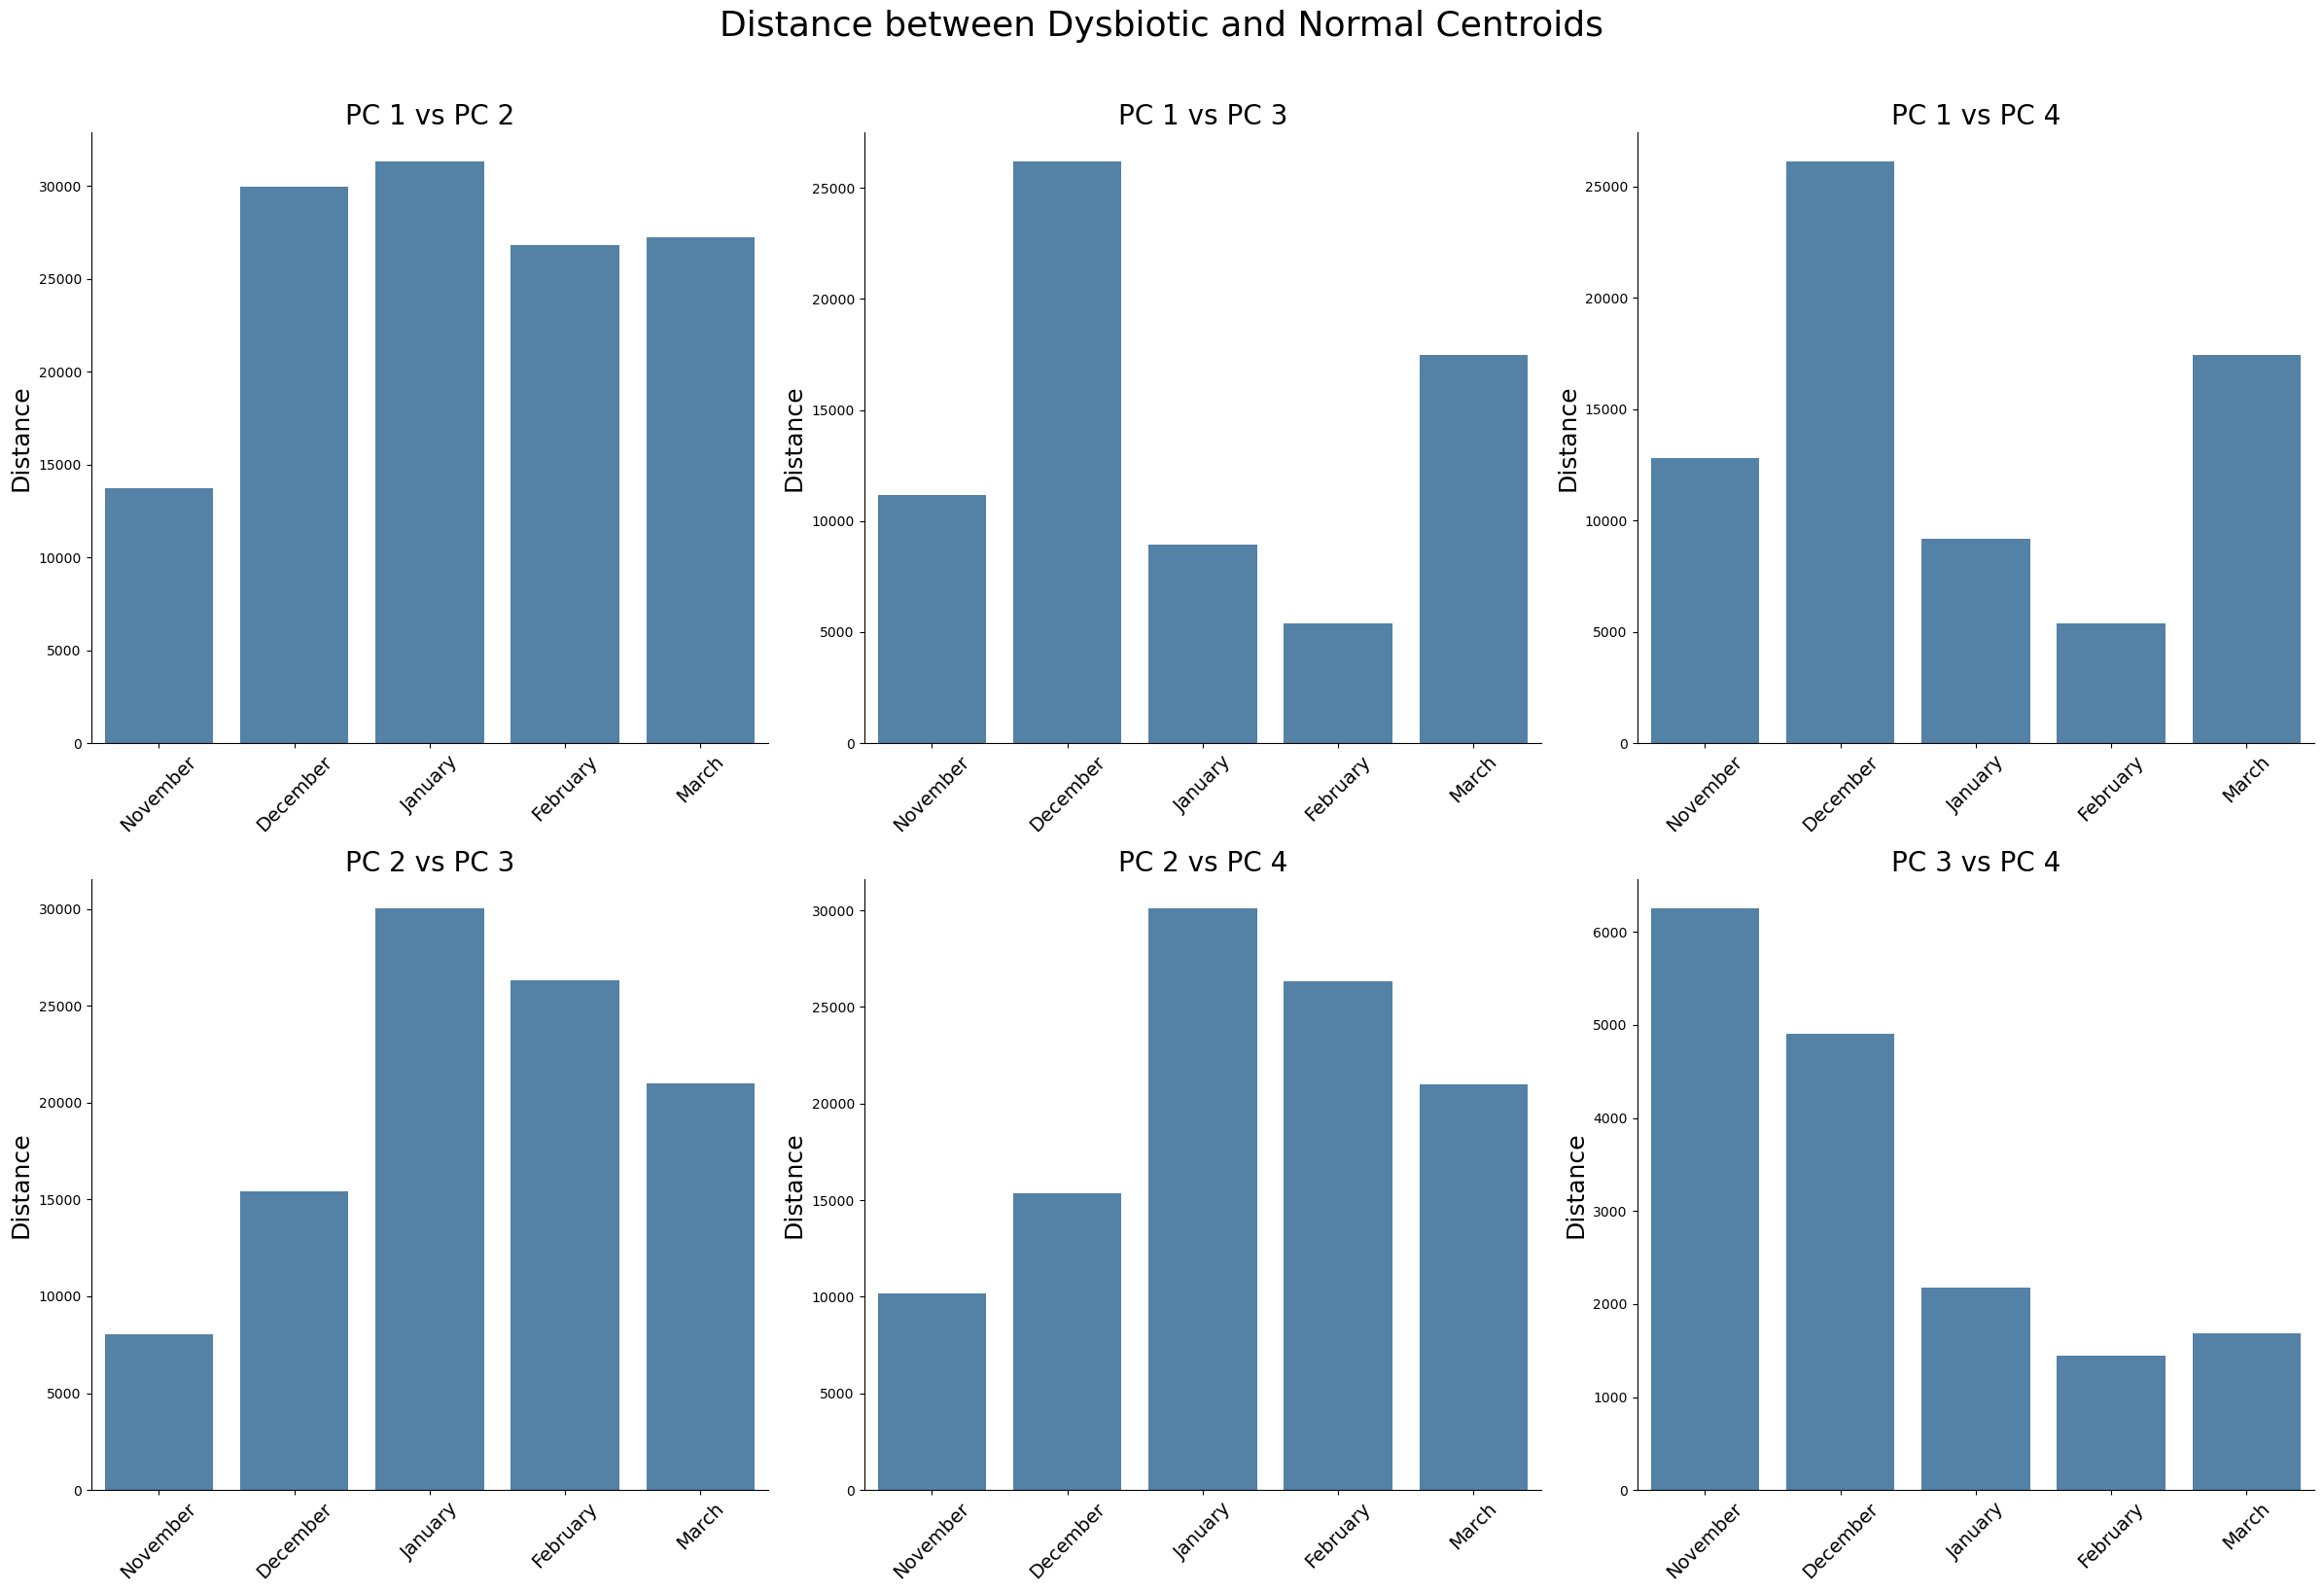

In [14]:
distance_data = []
months = centroids_multi["Sample Month"].unique()

for month in months:
    month_data = centroids_multi[centroids_multi["Sample Month"] == month]

    if (
        "Normal" in month_data["Dysbiosis Status"].values
        and "Dysbiotic" in month_data["Dysbiosis Status"].values
    ):
        normal_centroid = month_data[month_data["Dysbiosis Status"] == "Normal"]
        dysbiotic_centroid = month_data[month_data["Dysbiosis Status"] == "Dysbiotic"]

        for pc_x, pc_y in pairs:
            col_x = f"PC {pc_x}"
            col_y = f"PC {pc_y}"

            x_diff = (
                normal_centroid[col_x].values[0] - dysbiotic_centroid[col_x].values[0]
            )
            y_diff = (
                normal_centroid[col_y].values[0] - dysbiotic_centroid[col_y].values[0]
            )

            dist = np.sqrt(x_diff**2 + y_diff**2)

            distance_data.append(
                {
                    "Sample Month": month,
                    "PC Pair": f"PC {pc_x} vs PC {pc_y}",
                    "Distance": dist,
                }
            )

dist_df = pd.DataFrame(distance_data)

month_order = ["November", "December", "January", "February", "March"]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.patch.set_facecolor("white")
axes = axes.flatten()

for i, (pc_x, pc_y) in enumerate(pairs):
    ax = axes[i]
    pair_name = f"PC {pc_x} vs PC {pc_y}"

    plot_data = dist_df[dist_df["PC Pair"] == pair_name]

    sns.barplot(
        data=plot_data,
        x="Sample Month",
        y="Distance",
        ax=ax,
        color="steelblue",
        order=month_order,
    )

    ax.set_title(pair_name, fontsize=20)
    ax.set_xlabel("", fontsize=18)
    ax.set_ylabel("Distance", fontsize=18)
    ax.tick_params(axis="x", rotation=45, labelsize=14)
    sns.despine(ax=ax)

plt.suptitle("Distance between Dysbiotic and Normal Centroids", fontsize=26, y=1.02)
plt.tight_layout()
plt.show()

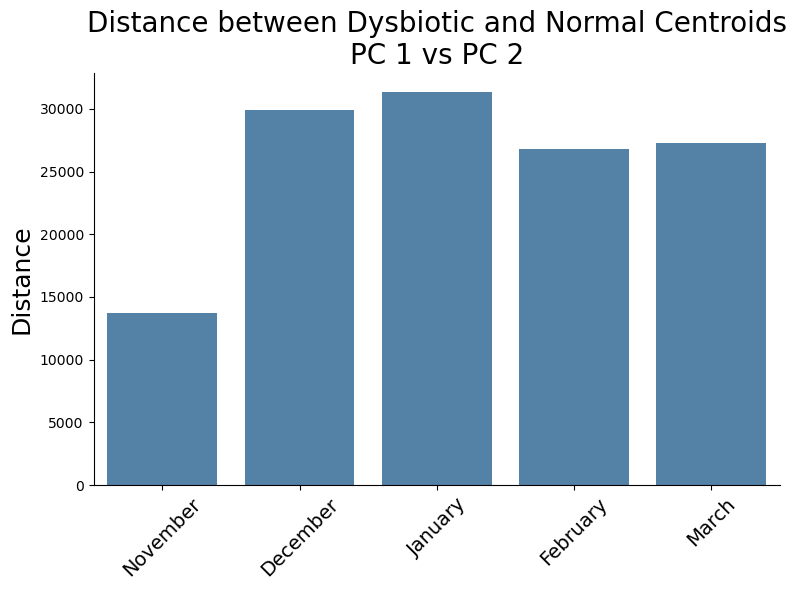

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("white")

pair_name = "PC 1 vs PC 2"
plot_data = dist_df[dist_df["PC Pair"] == pair_name]

sns.barplot(
    data=plot_data,
    x="Sample Month",
    y="Distance",
    ax=ax,
    color="steelblue",
    order=month_order,
)

ax.set_title(
    "Distance between Dysbiotic and Normal Centroids\nPC 1 vs PC 2", fontsize=20
)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("Distance", fontsize=18)
ax.tick_params(axis="x", rotation=45, labelsize=14)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

30 timepoints with both groups present (out of 54 total timepoints); 13 of them have a group with n = 1


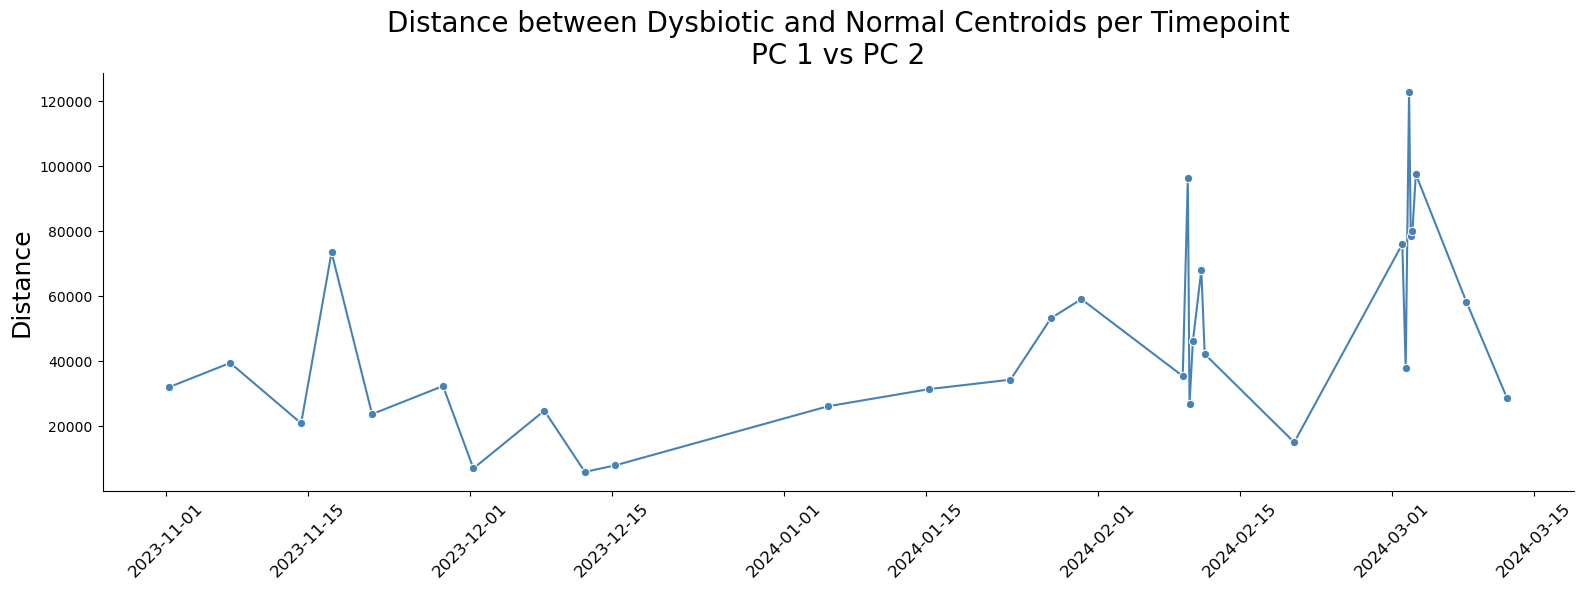

,Date and Time,timepoint,Distance,n Normal,n Dysbiotic
0,2023-11-01 08:00:00,t01,32037.562582,7,1
1,2023-11-07 08:00:00,t02,39455.840110,4,4
2,2023-11-14 08:00:00,t03,20874.413721,6,2
3,2023-11-17 08:00:00,t04,73471.405263,6,2
4,2023-11-21 08:00:00,t05,23689.960530,5,3
5,2023-11-28 08:00:00,t06,32344.514306,6,2
6,2023-12-01 08:00:00,t07,6981.493278,5,3
7,2023-12-08 08:00:00,t09,24758.660246,6,2
8,2023-12-12 08:00:00,t10,5914.151721,6,2
9,2023-12-15 08:00:00,t11,7928.402246,4,4


In [16]:
# Same distance, but per collection timepoint instead of binned by month
timepoint_pca = pca_df_multi.copy()
timepoint_pca["Date and Time"] = trimmed_metadata["Date and Time"]
timepoint_pca["timepoint"] = trimmed_metadata["timepoint"]

timepoint_centroids = (
    timepoint_pca.groupby(["Date and Time", "timepoint", "Dysbiosis Status"])[
        ["PC 1", "PC 2"]
    ]
    .mean()
    .reset_index()
)
timepoint_counts = (
    timepoint_pca.groupby(["Date and Time", "Dysbiosis Status"])
    .size()
    .unstack(fill_value=0)
)

timepoint_distance_data = []

for (date_time, timepoint), tp_data in timepoint_centroids.groupby(
    ["Date and Time", "timepoint"]
):
    statuses = tp_data["Dysbiosis Status"].values
    if "Normal" not in statuses or "Dysbiotic" not in statuses:
        continue

    normal_centroid = tp_data[tp_data["Dysbiosis Status"] == "Normal"]
    dysbiotic_centroid = tp_data[tp_data["Dysbiosis Status"] == "Dysbiotic"]

    x_diff = normal_centroid["PC 1"].values[0] - dysbiotic_centroid["PC 1"].values[0]
    y_diff = normal_centroid["PC 2"].values[0] - dysbiotic_centroid["PC 2"].values[0]

    timepoint_distance_data.append(
        {
            "Date and Time": date_time,
            "timepoint": timepoint,
            "Distance": np.sqrt(x_diff**2 + y_diff**2),
            "n Normal": int(timepoint_counts.loc[date_time, "Normal"]),
            "n Dysbiotic": int(timepoint_counts.loc[date_time, "Dysbiotic"]),
        }
    )

timepoint_dist_df = pd.DataFrame(timepoint_distance_data).sort_values("Date and Time")

# Timepoints where one of the groups has only a single sample give a very noisy
# centroid, so flag them rather than silently plotting them as equals
singleton_timepoints = timepoint_dist_df[
    (timepoint_dist_df["n Normal"] < 2) | (timepoint_dist_df["n Dysbiotic"] < 2)
]
print(
    f"{len(timepoint_dist_df)} timepoints with both groups present "
    f"(out of {timepoint_pca['Date and Time'].nunique()} total timepoints); "
    f"{len(singleton_timepoints)} of them have a group with n = 1"
)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor("white")

sns.lineplot(
    data=timepoint_dist_df,
    x="Date and Time",
    y="Distance",
    marker="o",
    color="steelblue",
    ax=ax,
)

ax.set_title(
    "Distance between Dysbiotic and Normal Centroids per Timepoint\nPC 1 vs PC 2",
    fontsize=20,
)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("Distance", fontsize=18)
ax.tick_params(axis="x", rotation=45, labelsize=12)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

timepoint_dist_df

19 timepoints with both groups present (out of 28 non-circadian timepoints); 5 of them have a group with n = 1


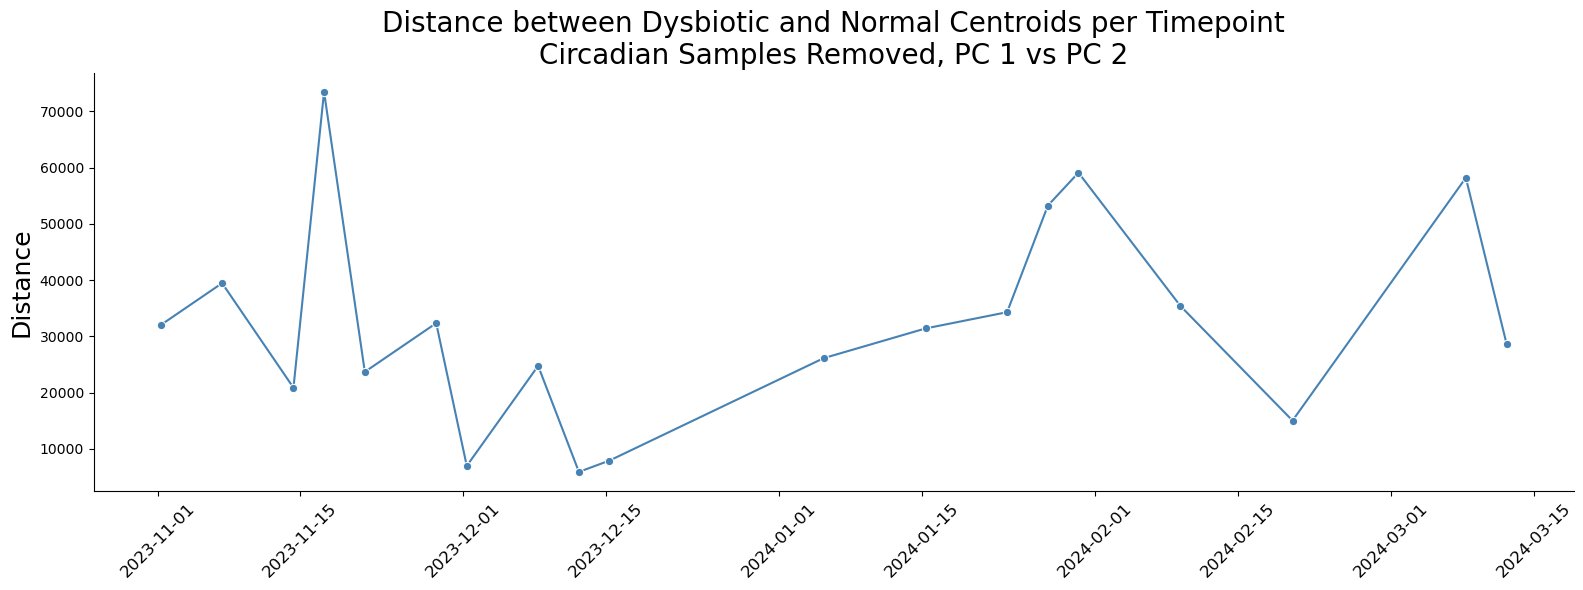

,Date and Time,timepoint,Distance,n Normal,n Dysbiotic
0,2023-11-01 08:00:00,t01,32037.562582,7,1
1,2023-11-07 08:00:00,t02,39455.840110,4,4
2,2023-11-14 08:00:00,t03,20874.413721,6,2
3,2023-11-17 08:00:00,t04,73471.405263,6,2
4,2023-11-21 08:00:00,t05,23689.960530,5,3
5,2023-11-28 08:00:00,t06,32344.514306,6,2
6,2023-12-01 08:00:00,t07,6981.493278,5,3
7,2023-12-08 08:00:00,t09,24758.660246,6,2
8,2023-12-12 08:00:00,t10,5914.151721,6,2
9,2023-12-15 08:00:00,t11,7928.402246,4,4


In [17]:
# Same per-timepoint distance, but with the circadian experiment samples removed
timepoint_pca_no_circadian = timepoint_pca[
    ~trimmed_metadata.loc[timepoint_pca.index, "Experiment Type"].isin(
        ["Circadian Experiment 1", "Circadian Experiment 2"]
    )
]

no_circadian_centroids = (
    timepoint_pca_no_circadian.groupby(
        ["Date and Time", "timepoint", "Dysbiosis Status"]
    )[["PC 1", "PC 2"]]
    .mean()
    .reset_index()
)
no_circadian_counts = (
    timepoint_pca_no_circadian.groupby(["Date and Time", "Dysbiosis Status"])
    .size()
    .unstack(fill_value=0)
)

no_circadian_distance_data = []

for (date_time, timepoint), tp_data in no_circadian_centroids.groupby(
    ["Date and Time", "timepoint"]
):
    statuses = tp_data["Dysbiosis Status"].values
    if "Normal" not in statuses or "Dysbiotic" not in statuses:
        continue

    normal_centroid = tp_data[tp_data["Dysbiosis Status"] == "Normal"]
    dysbiotic_centroid = tp_data[tp_data["Dysbiosis Status"] == "Dysbiotic"]

    x_diff = normal_centroid["PC 1"].values[0] - dysbiotic_centroid["PC 1"].values[0]
    y_diff = normal_centroid["PC 2"].values[0] - dysbiotic_centroid["PC 2"].values[0]

    no_circadian_distance_data.append(
        {
            "Date and Time": date_time,
            "timepoint": timepoint,
            "Distance": np.sqrt(x_diff**2 + y_diff**2),
            "n Normal": int(no_circadian_counts.loc[date_time, "Normal"]),
            "n Dysbiotic": int(no_circadian_counts.loc[date_time, "Dysbiotic"]),
        }
    )

no_circadian_dist_df = pd.DataFrame(no_circadian_distance_data).sort_values(
    "Date and Time"
)

no_circadian_singletons = no_circadian_dist_df[
    (no_circadian_dist_df["n Normal"] < 2) | (no_circadian_dist_df["n Dysbiotic"] < 2)
]
print(
    f"{len(no_circadian_dist_df)} timepoints with both groups present "
    f"(out of {timepoint_pca_no_circadian['Date and Time'].nunique()} non-circadian "
    f"timepoints); {len(no_circadian_singletons)} of them have a group with n = 1"
)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor("white")

sns.lineplot(
    data=no_circadian_dist_df,
    x="Date and Time",
    y="Distance",
    marker="o",
    color="steelblue",
    ax=ax,
)

ax.set_title(
    "Distance between Dysbiotic and Normal Centroids per Timepoint\n"
    "Circadian Samples Removed, PC 1 vs PC 2",
    fontsize=20,
)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("Distance", fontsize=18)
ax.tick_params(axis="x", rotation=45, labelsize=12)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

no_circadian_dist_df

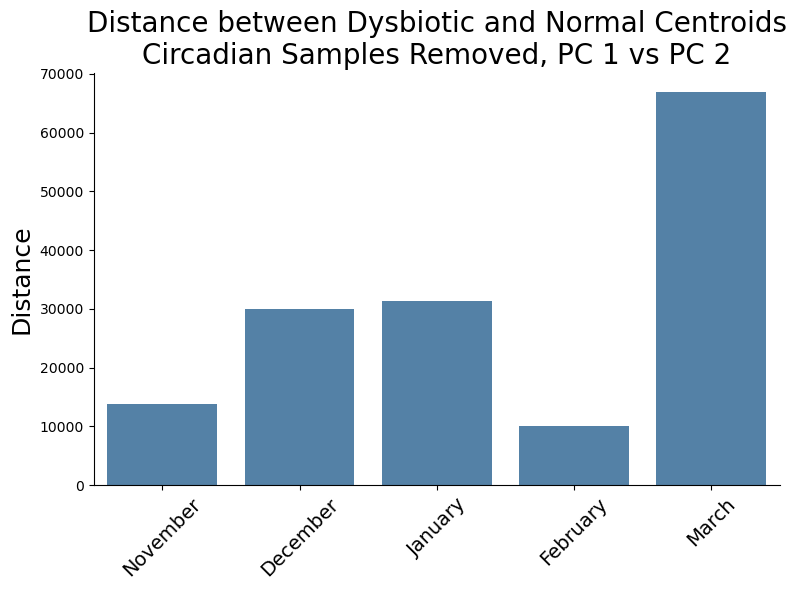

,Sample Month,Distance,n Normal,n Dysbiotic
0,November,13750.593727,34,14
1,December,29946.641914,29,11
2,January,31312.456202,28,11
3,February,10097.348881,53,3
4,March,66834.725622,36,4


In [18]:
# The monthly barplot from above, but with the circadian experiment samples removed.
# The PCA itself is left as is, matching how the other no-circadian cells filter samples.
month_pca_no_circadian = pca_df_multi[
    ~trimmed_metadata.loc[pca_df_multi.index, "Experiment Type"].isin(
        ["Circadian Experiment 1", "Circadian Experiment 2"]
    )
]

month_centroids_no_circadian = (
    month_pca_no_circadian.groupby(["Sample Month", "Dysbiosis Status"])[
        ["PC 1", "PC 2"]
    ]
    .mean()
    .reset_index()
)
month_counts_no_circadian = (
    month_pca_no_circadian.groupby(["Sample Month", "Dysbiosis Status"])
    .size()
    .unstack(fill_value=0)
)

month_distance_data_no_circadian = []

for month in month_order:
    month_data = month_centroids_no_circadian[
        month_centroids_no_circadian["Sample Month"] == month
    ]

    if (
        "Normal" in month_data["Dysbiosis Status"].values
        and "Dysbiotic" in month_data["Dysbiosis Status"].values
    ):
        normal_centroid = month_data[month_data["Dysbiosis Status"] == "Normal"]
        dysbiotic_centroid = month_data[month_data["Dysbiosis Status"] == "Dysbiotic"]

        x_diff = (
            normal_centroid["PC 1"].values[0] - dysbiotic_centroid["PC 1"].values[0]
        )
        y_diff = (
            normal_centroid["PC 2"].values[0] - dysbiotic_centroid["PC 2"].values[0]
        )

        month_distance_data_no_circadian.append(
            {
                "Sample Month": month,
                "Distance": np.sqrt(x_diff**2 + y_diff**2),
                "n Normal": int(month_counts_no_circadian.loc[month, "Normal"]),
                "n Dysbiotic": int(month_counts_no_circadian.loc[month, "Dysbiotic"]),
            }
        )
    else:
        print(f"Skipping {month}: only one dysbiosis group left after filtering")

month_dist_df_no_circadian = pd.DataFrame(month_distance_data_no_circadian)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("white")

sns.barplot(
    data=month_dist_df_no_circadian,
    x="Sample Month",
    y="Distance",
    ax=ax,
    color="steelblue",
    order=month_order,
)

ax.set_title(
    "Distance between Dysbiotic and Normal Centroids\n"
    "Circadian Samples Removed, PC 1 vs PC 2",
    fontsize=20,
)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("Distance", fontsize=18)
ax.tick_params(axis="x", rotation=45, labelsize=14)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

month_dist_df_no_circadian

In [19]:
# Instead of the distance between the two centroids, quantify how spread out each
# group is around its own centroid, and test that with PERMDISP
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permdisp

# Use the same two components as the centroid-distance barplot above
dispersion_cols = ["PC 1", "PC 2"]

dispersion_rows = []
permdisp_rows = []

for month in month_order:
    month_data = pca_df_multi[pca_df_multi["Sample Month"] == month]
    group_sizes = month_data["Dysbiosis Status"].value_counts()

    # PERMDISP needs a few samples in each group to be meaningful
    if not {"Normal", "Dysbiotic"}.issubset(group_sizes.index) or group_sizes.min() < 3:
        print(f"Skipping {month}: group sizes {group_sizes.to_dict()}")
        continue

    coords = month_data[dispersion_cols].to_numpy()
    dm = DistanceMatrix(squareform(pdist(coords)), ids=month_data.index.astype(str))

    result = permdisp(
        dm,
        grouping=month_data["Dysbiosis Status"].tolist(),
        test="centroid",
        permutations=999,
        seed=0,
    )
    permdisp_rows.append(
        {
            "Sample Month": month,
            "F-value": result["test statistic"],
            "p-value": result["p-value"],
            "n Normal": int(group_sizes["Normal"]),
            "n Dysbiotic": int(group_sizes["Dysbiotic"]),
        }
    )

    # PERMDISP itself only reports the F-test, so recompute the per-group distances
    # to centroid (the values PERMDISP tests) to get the dispersion of each group
    for status in ["Normal", "Dysbiotic"]:
        group_coords = month_data.loc[
            month_data["Dysbiosis Status"] == status, dispersion_cols
        ].to_numpy()
        centroid = group_coords.mean(axis=0)
        distances_to_centroid = np.linalg.norm(group_coords - centroid, axis=1)

        dispersion_rows.append(
            {
                "Sample Month": month,
                "Dysbiosis Status": status,
                "Dispersion": distances_to_centroid.mean(),
                "SE": distances_to_centroid.std(ddof=1)
                / np.sqrt(len(distances_to_centroid)),
                "n": len(distances_to_centroid),
            }
        )

dispersion_df = pd.DataFrame(dispersion_rows)
permdisp_df = pd.DataFrame(permdisp_rows)

print("PERMDISP (Normal vs Dysbiotic dispersion, PC 1 vs PC 2):")
print(permdisp_df.to_string(index=False))
permdisp_df

PERMDISP (Normal vs Dysbiotic dispersion, PC 1 vs PC 2):
Sample Month  F-value  p-value  n Normal  n Dysbiotic
    November 0.001284    0.971        34           14
    December 0.186099    0.748        29           11
     January 0.082928    0.746        28           11
    February 2.779810    0.122       149           11
       March 5.351615    0.024       133           10


,Sample Month,F-value,p-value,n Normal,n Dysbiotic
0,November,0.001284,0.971,34,14
1,December,0.186099,0.748,29,11
2,January,0.082928,0.746,28,11
3,February,2.779810,0.122,149,11
4,March,5.351615,0.024,133,10


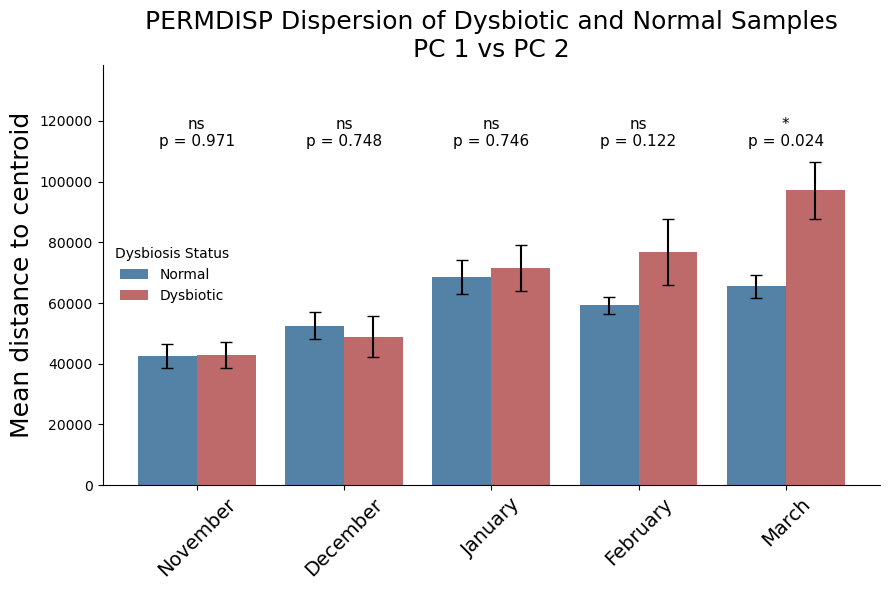

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")

plot_order = [m for m in month_order if m in set(dispersion_df["Sample Month"])]

sns.barplot(
    data=dispersion_df,
    x="Sample Month",
    y="Dispersion",
    hue="Dysbiosis Status",
    hue_order=["Normal", "Dysbiotic"],
    order=plot_order,
    palette={"Normal": "steelblue", "Dysbiotic": "indianred"},
    ax=ax,
)

# Add the standard errors of the distances to centroid as error bars
bar_lookup = {
    (row["Sample Month"], row["Dysbiosis Status"]): row
    for _, row in dispersion_df.iterrows()
}
for container, status in zip(ax.containers, ["Normal", "Dysbiotic"]):
    for bar, month in zip(container, plot_order):
        row = bar_lookup[(month, status)]
        ax.errorbar(
            bar.get_x() + bar.get_width() / 2,
            row["Dispersion"],
            yerr=row["SE"],
            color="black",
            capsize=4,
            linewidth=1.5,
        )

# Annotate each month with its PERMDISP p-value
y_max = (dispersion_df["Dispersion"] + dispersion_df["SE"]).max()
for i, month in enumerate(plot_order):
    p = permdisp_df.loc[permdisp_df["Sample Month"] == month, "p-value"].values[0]
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(
        i, y_max * 1.04, f"{stars}\np = {p:.3f}", ha="center", va="bottom", fontsize=11
    )

ax.set_ylim(0, y_max * 1.30)
ax.set_title(
    "PERMDISP Dispersion of Dysbiotic and Normal Samples\nPC 1 vs PC 2", fontsize=18
)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("Mean distance to centroid", fontsize=18)
ax.tick_params(axis="x", rotation=45, labelsize=14)
ax.legend(title="Dysbiosis Status", frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

PERMDISP across months (all samples, PC 1 vs PC 2):
method name               PERMDISP
test statistic name        F-value
sample size                    430
number of groups                 5
test statistic            5.876435
p-value                      0.003
number of permutations         999

Sample Month   Dispersion          SE   n
    November 43006.372582 3091.197414  48
    December 52125.427242 4114.007645  40
     January 70705.157507 4621.613057  39
    February 60550.543381 2723.303998 160
       March 67859.224936 3565.282815 143


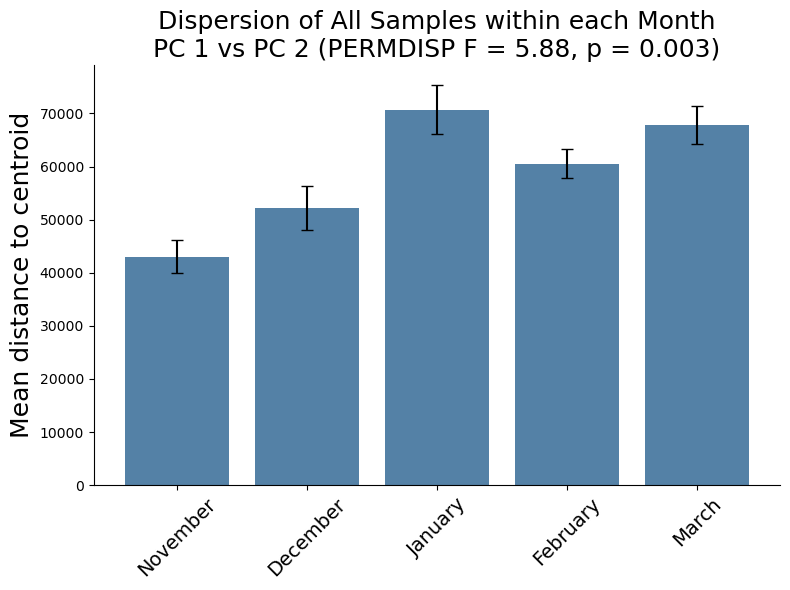

In [21]:
# Dispersion of each month using all samples combined, ignoring dysbiosis status.
# Here PERMDISP is run once across all samples with the month as the grouping, so
# it tests whether the months differ from each other in how spread out they are.
all_samples_dm = DistanceMatrix(
    squareform(pdist(pca_df_multi[dispersion_cols].to_numpy())),
    ids=pca_df_multi.index.astype(str),
)

all_samples_permdisp = permdisp(
    all_samples_dm,
    grouping=pca_df_multi["Sample Month"].tolist(),
    test="centroid",
    permutations=999,
    seed=0,
)

# Per-month distances to that month's own centroid
all_samples_rows = []
for month in month_order:
    month_coords = pca_df_multi.loc[
        pca_df_multi["Sample Month"] == month, dispersion_cols
    ].to_numpy()
    centroid = month_coords.mean(axis=0)
    distances_to_centroid = np.linalg.norm(month_coords - centroid, axis=1)

    all_samples_rows.append(
        {
            "Sample Month": month,
            "Dispersion": distances_to_centroid.mean(),
            "SE": distances_to_centroid.std(ddof=1)
            / np.sqrt(len(distances_to_centroid)),
            "n": len(distances_to_centroid),
        }
    )

all_samples_dispersion_df = pd.DataFrame(all_samples_rows)

print("PERMDISP across months (all samples, PC 1 vs PC 2):")
print(all_samples_permdisp.to_string())
print()
print(all_samples_dispersion_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("white")

sns.barplot(
    data=all_samples_dispersion_df,
    x="Sample Month",
    y="Dispersion",
    order=month_order,
    color="steelblue",
    ax=ax,
)

plotted = all_samples_dispersion_df.set_index("Sample Month").loc[month_order]
ax.errorbar(
    np.arange(len(month_order)),
    plotted["Dispersion"],
    yerr=plotted["SE"],
    fmt="none",
    color="black",
    capsize=4,
    linewidth=1.5,
)

f_value = all_samples_permdisp["test statistic"]
p_value = all_samples_permdisp["p-value"]
ax.set_title(
    "Dispersion of All Samples within each Month\n"
    f"PC 1 vs PC 2 (PERMDISP F = {f_value:.2f}, p = {p_value:.3f})",
    fontsize=18,
)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("Mean distance to centroid", fontsize=18)
ax.tick_params(axis="x", rotation=45, labelsize=14)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Samples remaining per month:
Sample Month
February    56
November    48
December    40
March       40
January     39



PERMDISP across months (no circadian, PC 1 vs PC 2):
method name               PERMDISP
test statistic name        F-value
sample size                    223
number of groups                 5
test statistic            5.519797
p-value                      0.001
number of permutations         999

Sample Month   Dispersion          SE  n
    November 43006.372582 3091.197414 48
    December 52125.427242 4114.007645 40
     January 70705.157507 4621.613057 39
    February 49373.454382 4194.426090 56
       March 60221.558881 6169.599697 40


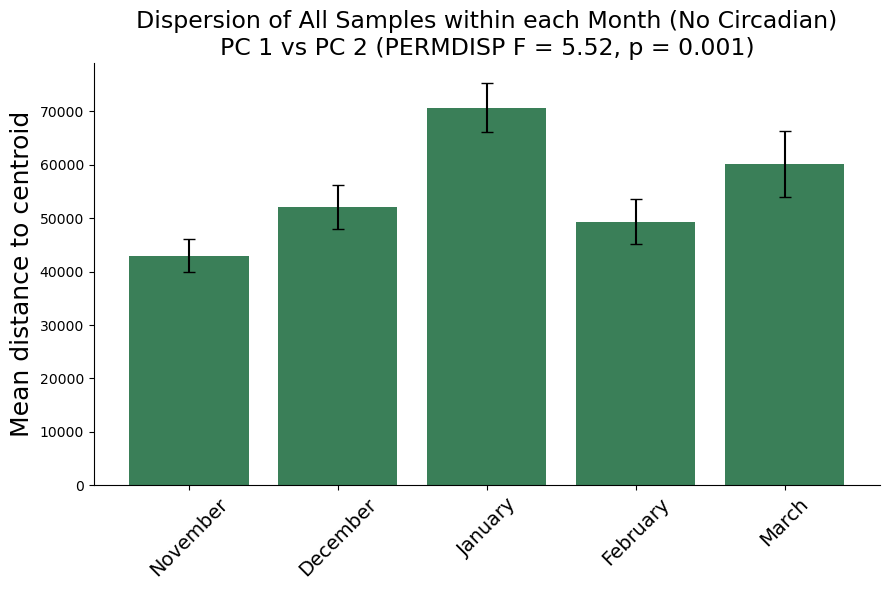

In [22]:
# Same all-samples-per-month dispersion, but with the circadian experiments removed.
# The PCA coordinates are the ones already computed on the full set of samples,
# these are just subset down to the long term samples.
pca_df_multi["Experiment Type"] = trimmed_metadata["Experiment Type"]
pca_df_multi_no_circadian = pca_df_multi[
    ~pca_df_multi["Experiment Type"].isin(
        ["Circadian Experiment 1", "Circadian Experiment 2"]
    )
]

no_circadian_month_order = [
    month
    for month in month_order
    if (pca_df_multi_no_circadian["Sample Month"] == month).sum() >= 3
]
print("Samples remaining per month:")
print(pca_df_multi_no_circadian["Sample Month"].value_counts().to_string())
print()

no_circadian_dm = DistanceMatrix(
    squareform(pdist(pca_df_multi_no_circadian[dispersion_cols].to_numpy())),
    ids=pca_df_multi_no_circadian.index.astype(str),
)

no_circadian_permdisp = permdisp(
    no_circadian_dm,
    grouping=pca_df_multi_no_circadian["Sample Month"].tolist(),
    test="centroid",
    permutations=999,
    seed=0,
)

no_circadian_rows = []
for month in no_circadian_month_order:
    month_coords = pca_df_multi_no_circadian.loc[
        pca_df_multi_no_circadian["Sample Month"] == month, dispersion_cols
    ].to_numpy()
    centroid = month_coords.mean(axis=0)
    distances_to_centroid = np.linalg.norm(month_coords - centroid, axis=1)

    no_circadian_rows.append(
        {
            "Sample Month": month,
            "Dispersion": distances_to_centroid.mean(),
            "SE": distances_to_centroid.std(ddof=1)
            / np.sqrt(len(distances_to_centroid)),
            "n": len(distances_to_centroid),
        }
    )

no_circadian_dispersion_df = pd.DataFrame(no_circadian_rows)

print("PERMDISP across months (no circadian, PC 1 vs PC 2):")
print(no_circadian_permdisp.to_string())
print()
print(no_circadian_dispersion_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")

sns.barplot(
    data=no_circadian_dispersion_df,
    x="Sample Month",
    y="Dispersion",
    order=no_circadian_month_order,
    color="seagreen",
    ax=ax,
)

plotted = no_circadian_dispersion_df.set_index("Sample Month").loc[
    no_circadian_month_order
]
ax.errorbar(
    np.arange(len(no_circadian_month_order)),
    plotted["Dispersion"],
    yerr=plotted["SE"],
    fmt="none",
    color="black",
    capsize=4,
    linewidth=1.5,
)

f_value = no_circadian_permdisp["test statistic"]
p_value = no_circadian_permdisp["p-value"]
ax.set_title(
    "Dispersion of All Samples within each Month (No Circadian)\n"
    f"PC 1 vs PC 2 (PERMDISP F = {f_value:.2f}, p = {p_value:.3f})",
    fontsize=17,
)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("Mean distance to centroid", fontsize=18)
ax.tick_params(axis="x", rotation=45, labelsize=14)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

PERMDISP across months (no circadian, recomputed PCA, PC 1 vs PC 2):
method name               PERMDISP
test statistic name        F-value
sample size                    223
number of groups                 5
test statistic             5.57297
p-value                      0.001
number of permutations         999

Sample Month   Dispersion          SE  n
    November 42947.161499 3085.864435 48
    December 52180.338221 4116.561311 40
     January 70789.221496 4619.798787 39
    February 49334.694390 4194.758099 56
       March 60215.629759 6169.055423 40


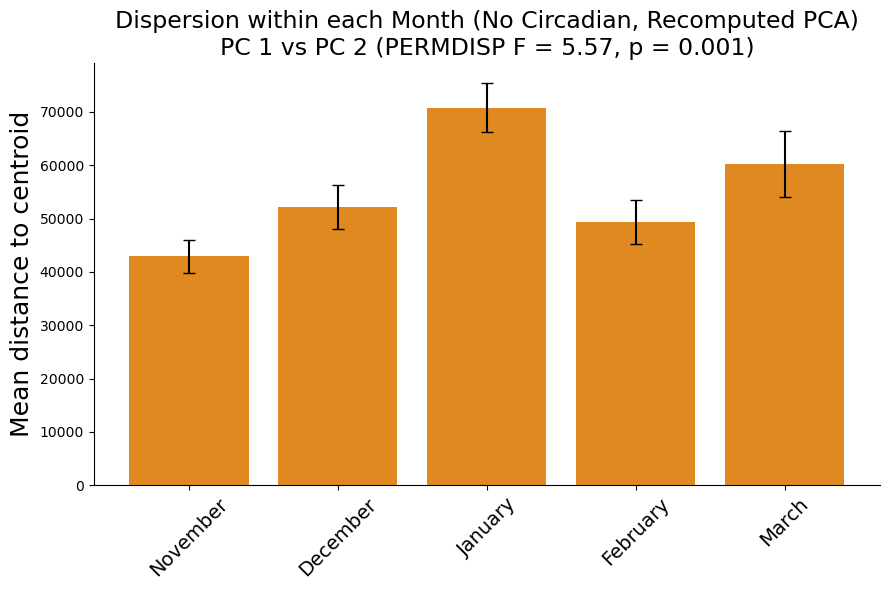

In [23]:
# Same again, but with the PCA recalculated on only the non circadian samples,
# rather than subsetting coordinates that were fitted to the full sample set.
recomputed_no_circadian_meta = trimmed_metadata[
    ~trimmed_metadata["Experiment Type"].isin(
        ["Circadian Experiment 1", "Circadian Experiment 2"]
    )
]
recomputed_pca = sklearn.decomposition.PCA(n_components=5).fit_transform(
    trimmed_transcriptome.loc[recomputed_no_circadian_meta.index]
)

pca_df_multi_recomputed = pd.DataFrame(
    recomputed_pca[:, :4],
    columns=["PC 1", "PC 2", "PC 3", "PC 4"],
    index=recomputed_no_circadian_meta.index,
)
pca_df_multi_recomputed["Sample Month"] = recomputed_no_circadian_meta["Sample Month"]
pca_df_multi_recomputed["Dysbiosis Status"] = recomputed_no_circadian_meta[
    "Dysbiosis Status"
]

recomputed_month_order = [
    month
    for month in month_order
    if (pca_df_multi_recomputed["Sample Month"] == month).sum() >= 3
]

recomputed_dm = DistanceMatrix(
    squareform(pdist(pca_df_multi_recomputed[dispersion_cols].to_numpy())),
    ids=pca_df_multi_recomputed.index.astype(str),
)

recomputed_permdisp = permdisp(
    recomputed_dm,
    grouping=pca_df_multi_recomputed["Sample Month"].tolist(),
    test="centroid",
    permutations=999,
    seed=0,
)

recomputed_rows = []
for month in recomputed_month_order:
    month_coords = pca_df_multi_recomputed.loc[
        pca_df_multi_recomputed["Sample Month"] == month, dispersion_cols
    ].to_numpy()
    centroid = month_coords.mean(axis=0)
    distances_to_centroid = np.linalg.norm(month_coords - centroid, axis=1)

    recomputed_rows.append(
        {
            "Sample Month": month,
            "Dispersion": distances_to_centroid.mean(),
            "SE": distances_to_centroid.std(ddof=1)
            / np.sqrt(len(distances_to_centroid)),
            "n": len(distances_to_centroid),
        }
    )

recomputed_dispersion_df = pd.DataFrame(recomputed_rows)

print("PERMDISP across months (no circadian, recomputed PCA, PC 1 vs PC 2):")
print(recomputed_permdisp.to_string())
print()
print(recomputed_dispersion_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")

sns.barplot(
    data=recomputed_dispersion_df,
    x="Sample Month",
    y="Dispersion",
    order=recomputed_month_order,
    color="darkorange",
    ax=ax,
)

plotted = recomputed_dispersion_df.set_index("Sample Month").loc[recomputed_month_order]
ax.errorbar(
    np.arange(len(recomputed_month_order)),
    plotted["Dispersion"],
    yerr=plotted["SE"],
    fmt="none",
    color="black",
    capsize=4,
    linewidth=1.5,
)

f_value = recomputed_permdisp["test statistic"]
p_value = recomputed_permdisp["p-value"]
ax.set_title(
    "Dispersion within each Month (No Circadian, Recomputed PCA)\n"
    f"PC 1 vs PC 2 (PERMDISP F = {f_value:.2f}, p = {p_value:.3f})",
    fontsize=17,
)
ax.set_xlabel("", fontsize=18)
ax.set_ylabel("Mean distance to centroid", fontsize=18)
ax.tick_params(axis="x", rotation=45, labelsize=14)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [24]:
# Regress PCA 1 and 2 against total days passed
import statsmodels.api as sm

# We can use the 'daysincestart' from the metadata
pca_df["daysincestart"] = trimmed_metadata["daysincestart"]

X = sm.add_constant(pca_df["daysincestart"])
y1 = pca_df["PCA 1"]
model_pc1 = sm.OLS(y1, X).fit()

y2 = pca_df["PCA 2"]
model_pc2 = sm.OLS(y2, X).fit()

print("Transcriptome PC1 vs Days Since Start:")
print(model_pc1.summary().tables[1])
print("\nTranscriptome PC2 vs Days Since Start:")
print(model_pc2.summary().tables[1])

Transcriptome PC1 vs Days Since Start:
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -9.901e+04   7601.950    -13.024      0.000   -1.14e+05   -8.41e+04
daysincestart  1079.3209     76.756     14.062      0.000     928.456    1230.186

Transcriptome PC2 vs Days Since Start:
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.267e+04   5225.254     -2.425      0.016   -2.29e+04   -2402.678
daysincestart   138.1554     52.758      2.619      0.009      34.458     241.853


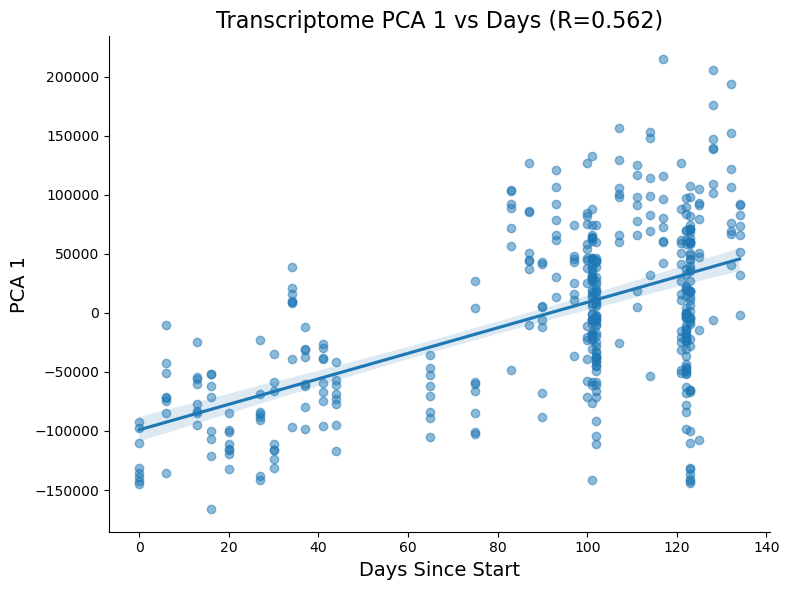

In [25]:
# Plot regressions for Transcriptome PC1 vs daysincestart
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=pca_df, x="daysincestart", y="PCA 1", ax=ax, scatter_kws={"alpha": 0.5}
)
r, _ = stats.pearsonr(pca_df["daysincestart"], pca_df["PCA 1"])
ax.set_title(f"Transcriptome PCA 1 vs Days (R={r:.3f})", fontsize=16)
ax.set_xlabel("Days Since Start", fontsize=14)
ax.set_ylabel("PCA 1", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

## Microbiome PCA (commented out)

The microbiome-PCA cells below are commented out: Luke is redoing the microbiome ordination for the recalled genera. They still point to the old species-level `AT_16S_ord_total.csv`. The transcriptome-only regressions are left active.

In [26]:
## Microbiome PCA: commented out, Luke is redoing the ordination
# # Regress Microbiome PCA 1 and 2 against total days passed
# microbiome_pca = pd.read_csv(
#     "/Users/michael/Data/Luke_terrace_experiment/Microbiome/AT_16S_ord_total.csv"
# )
#
# # Drop any rows with NaN in PCs or daysincestart
# microbiome_pca = microbiome_pca.dropna(subset=["PC1", "PC2", "daysincestart"])
#
# X_mic = sm.add_constant(microbiome_pca["daysincestart"])
# y1_mic = microbiome_pca["PC1"]
# model_mic_pc1 = sm.OLS(y1_mic, X_mic).fit()
#
# y2_mic = microbiome_pca["PC2"]
# model_mic_pc2 = sm.OLS(y2_mic, X_mic).fit()
#
# print("Microbiome PC1 vs Days Since Start:")
# print(model_mic_pc1.summary().tables[1])
# print("\nMicrobiome PC2 vs Days Since Start:")
# print(model_mic_pc2.summary().tables[1])

In [27]:
## Microbiome PCA: commented out, Luke is redoing the ordination
# # Plot regressions for Microbiome PC1 vs daysincestart
# fig, ax = plt.subplots(figsize=(8, 6))
#
# sns.regplot(
#     data=microbiome_pca,
#     x="daysincestart",
#     y="PC1",
#     ax=ax,
#     scatter_kws={"alpha": 0.5},
#     color="orange",
# )
# r, _ = stats.pearsonr(microbiome_pca["daysincestart"], microbiome_pca["PC1"])
# ax.set_title(f"Microbiome PC1 vs Days (R={r:.3f})", fontsize=16)
# ax.set_xlabel("Days Since Start", fontsize=14)
# ax.set_ylabel("PC1", fontsize=14)
#
# sns.despine()
# plt.tight_layout()
# plt.show()

In [28]:
# Regress PCA 1 and 2 against total days passed, excluding Circadian experiments
# Add Experiment Type to pca_df to filter
pca_df["Experiment Type"] = trimmed_metadata["Experiment Type"]
pca_df_filtered = pca_df[
    ~pca_df["Experiment Type"].isin(
        ["Circadian Experiment 1", "Circadian Experiment 2"]
    )
]

X_filtered = sm.add_constant(pca_df_filtered["daysincestart"])
y1_filtered = pca_df_filtered["PCA 1"]
model_pc1_filtered = sm.OLS(y1_filtered, X_filtered).fit()

y2_filtered = pca_df_filtered["PCA 2"]
model_pc2_filtered = sm.OLS(y2_filtered, X_filtered).fit()

print("Transcriptome PC1 vs Days Since Start (Excluding Circadian):")
print(model_pc1_filtered.summary().tables[1])
print(f"R-squared: {model_pc1_filtered.rsquared:.3f}")

print("\nTranscriptome PC2 vs Days Since Start (Excluding Circadian):")
print(model_pc2_filtered.summary().tables[1])
print(f"R-squared: {model_pc2_filtered.rsquared:.3f}")

Transcriptome PC1 vs Days Since Start (Excluding Circadian):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.151e+05   6827.789    -16.851      0.000   -1.29e+05   -1.02e+05
daysincestart  1589.2616     80.462     19.752      0.000    1430.691    1747.832
R-squared: 0.638

Transcriptome PC2 vs Days Since Start (Excluding Circadian):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.461e+04   5077.030     -2.878      0.004   -2.46e+04   -4603.692
daysincestart   117.5403     59.830      1.965      0.051      -0.370     235.451
R-squared: 0.017


In [29]:
## Microbiome PCA: commented out, Luke is redoing the ordination
# # Regress Microbiome PCA 1 and 2 against total days passed, excluding Circadian experiments
# microbiome_pca_merged = microbiome_pca.merge(
#     metadata[["sampID", "Experiment Type"]],
#     left_on="SampleID",
#     right_on="sampID",
#     how="left",
# )
# microbiome_pca_filtered = microbiome_pca_merged[
#     ~microbiome_pca_merged["Experiment Type"].isin(
#         ["Circadian Experiment 1", "Circadian Experiment 2"]
#     )
# ]
#
# # Filter out NaNs if any are leftover
# microbiome_pca_filtered = microbiome_pca_filtered.dropna(
#     subset=["PC1", "PC2", "daysincestart"]
# )
#
# X_mic_filtered = sm.add_constant(microbiome_pca_filtered["daysincestart"])
# y1_mic_filtered = microbiome_pca_filtered["PC1"]
# model_mic_pc1_filtered = sm.OLS(y1_mic_filtered, X_mic_filtered).fit()
#
# y2_mic_filtered = microbiome_pca_filtered["PC2"]
# model_mic_pc2_filtered = sm.OLS(y2_mic_filtered, X_mic_filtered).fit()
#
# print("Microbiome PC1 vs Days Since Start (Excluding Circadian):")
# print(model_mic_pc1_filtered.summary().tables[1])
# print(f"R-squared: {model_mic_pc1_filtered.rsquared:.3f}")
#
# print("\nMicrobiome PC2 vs Days Since Start (Excluding Circadian):")
# print(model_mic_pc2_filtered.summary().tables[1])
# print(f"R-squared: {model_mic_pc2_filtered.rsquared:.3f}")

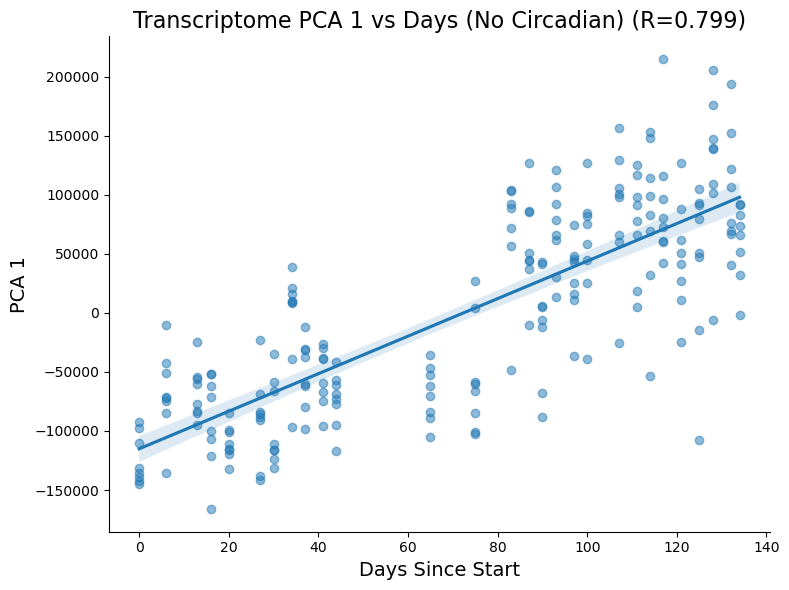

In [30]:
# Plot regressions for Transcriptome PC1 vs daysincestart (excluding Circadian)
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=pca_df_filtered,
    x="daysincestart",
    y="PCA 1",
    ax=ax,
    scatter_kws={"alpha": 0.5},
)
r, _ = stats.pearsonr(pca_df_filtered["daysincestart"], pca_df_filtered["PCA 1"])
ax.set_title(
    f"Transcriptome PCA 1 vs Days (No Circadian) (R={r:.3f})",
    fontsize=16,
)
ax.set_xlabel("Days Since Start", fontsize=14)
ax.set_ylabel("PCA 1", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

In [31]:
## Microbiome PCA: commented out, Luke is redoing the ordination
# # Plot regressions for Microbiome PC1 vs daysincestart (excluding Circadian)
# fig, ax = plt.subplots(figsize=(8, 6))
#
# sns.regplot(
#     data=microbiome_pca_filtered,
#     x="daysincestart",
#     y="PC1",
#     ax=ax,
#     scatter_kws={"alpha": 0.5},
#     color="orange",
# )
# r, _ = stats.pearsonr(
#     microbiome_pca_filtered["daysincestart"], microbiome_pca_filtered["PC1"]
# )
# ax.set_title(
#     f"Microbiome PC1 vs Days (No Circadian) (R={r:.3f})",
#     fontsize=16,
# )
# ax.set_xlabel("Days Since Start", fontsize=14)
# ax.set_ylabel("PC1", fontsize=14)
#
# sns.despine()
# plt.tight_layout()
# plt.show()

In [32]:
# Redo PCA on transcriptome data excluding Circadian experiments
circadian_experiments = ["Circadian Experiment 1", "Circadian Experiment 2"]
transcriptome_no_circadian_meta = trimmed_metadata[
    ~trimmed_metadata["Experiment Type"].isin(circadian_experiments)
]
transcriptome_no_circadian = trimmed_transcriptome.loc[
    transcriptome_no_circadian_meta.index
]

pca_no_circadian_model = sklearn.decomposition.PCA(n_components=5)
pca_no_circadian = pca_no_circadian_model.fit_transform(transcriptome_no_circadian)

# Create a DataFrame for the new PCA
pca_df_no_circadian = pd.DataFrame(
    pca_no_circadian[:, :2],
    columns=["PCA 1", "PCA 2"],
    index=transcriptome_no_circadian_meta.index,
)
pca_df_no_circadian["Sample Month"] = transcriptome_no_circadian_meta["Sample Month"]
pca_df_no_circadian["Dysbiosis Status"] = transcriptome_no_circadian_meta[
    "Dysbiosis Status"
]
pca_df_no_circadian["daysincestart"] = transcriptome_no_circadian_meta["daysincestart"]

# Run the regression on the new PCA 1
X_new_pca = sm.add_constant(pca_df_no_circadian["daysincestart"])
y1_new_pca = pca_df_no_circadian["PCA 1"]
model_pc1_new_pca = sm.OLS(y1_new_pca, X_new_pca).fit()

print("Recomputed Transcriptome PC1 vs Days Since Start (Excluding Circadian):")
print(model_pc1_new_pca.summary().tables[1])
print(f"R-squared: {model_pc1_new_pca.rsquared:.3f}")

Recomputed Transcriptome PC1 vs Days Since Start (Excluding Circadian):
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -1.165e+05   6813.772    -17.096      0.000    -1.3e+05   -1.03e+05
daysincestart  1594.3474     80.297     19.856      0.000    1436.102    1752.593
R-squared: 0.641


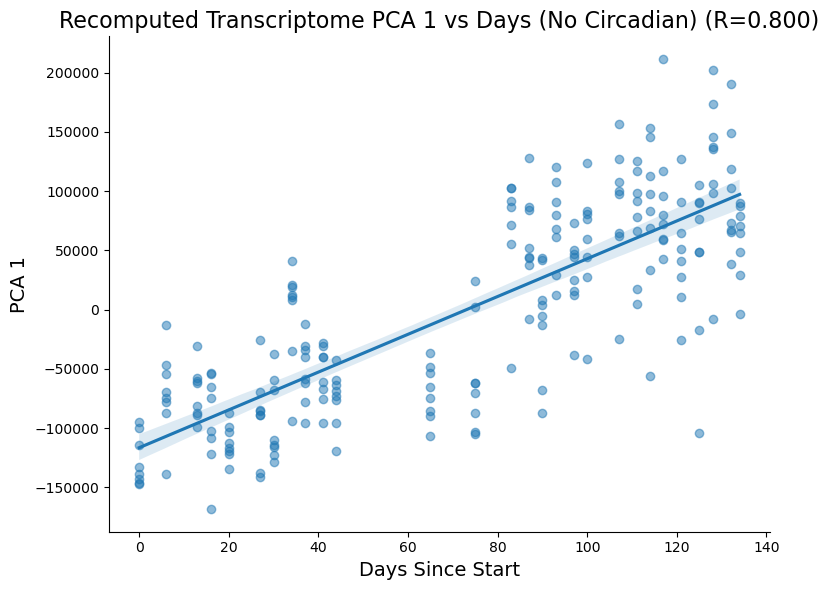

In [33]:
# Plot regression for Recomputed Transcriptome PC1 vs daysincestart (excluding Circadian)
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=pca_df_no_circadian,
    x="daysincestart",
    y="PCA 1",
    ax=ax,
    scatter_kws={"alpha": 0.5},
)
r, _ = stats.pearsonr(
    pca_df_no_circadian["daysincestart"], pca_df_no_circadian["PCA 1"]
)
ax.set_title(
    f"Recomputed Transcriptome PCA 1 vs Days (No Circadian) (R={r:.3f})",
    fontsize=16,
)
ax.set_xlabel("Days Since Start", fontsize=14)
ax.set_ylabel("PCA 1", fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

In [34]:
## Microbiome PCA: commented out, Luke is redoing the ordination
# # Plot Transcriptome PC1 vs Microbiome PC1 (With Circadian)
# # First we need to merge the PCA dataframes on sampID/SampleID
# pca_df["sampID"] = trimmed_metadata["sampID"]
# merged_pcas = pca_df.merge(microbiome_pca_merged, left_on="sampID", right_on="SampleID")
#
# fig, ax = plt.subplots(figsize=(8, 6))
#
# # Plot the scatter plot colored by daysincestart_x (created during merge)
# sns.scatterplot(
#     data=merged_pcas,
#     x="PCA 1",
#     y="PC1",
#     hue="daysincestart_x",
#     palette="viridis",
#     alpha=0.8,
#     ax=ax,
# )
#
# # Overlay the regression line
# sns.regplot(data=merged_pcas, x="PCA 1", y="PC1", ax=ax, scatter=False, color="black")
#
# # Using dropna just in case to safely compute pearson r
# clean_merged = merged_pcas.dropna(subset=["PCA 1", "PC1"])
# r_trans_mic, _ = stats.pearsonr(clean_merged["PCA 1"], clean_merged["PC1"])
#
# ax.set_title(f"Transcriptome PC1 vs Microbiome PC1 (R={r_trans_mic:.3f})", fontsize=16)
# ax.set_xlabel("Transcriptome PCA 1", fontsize=14)
# ax.set_ylabel("Microbiome PC1", fontsize=14)
#
# # Safely set legend title if present
# if ax.get_legend() is not None:
#     ax.get_legend().set_title("Days Since Start")
#
# sns.despine()
# plt.tight_layout()
# plt.show()

In [35]:
## Microbiome PCA: commented out, Luke is redoing the ordination
# # Plot Transcriptome PC1 vs Microbiome PC1 (Excluding Circadian)
# # We use the original transcriptome PCA filtered to exclude circadian samples (pca_df_filtered)
# pca_df_filtered = pca_df_filtered.copy()
# pca_df_filtered["sampID"] = trimmed_metadata.loc[pca_df_filtered.index, "sampID"]
# merged_pcas_no_circadian = pca_df_filtered.merge(
#     microbiome_pca_filtered, left_on="sampID", right_on="SampleID"
# )
#
# fig, ax = plt.subplots(figsize=(8, 6))
#
# # Plot the scatter plot colored by daysincestart_x (created during merge)
# sns.scatterplot(
#     data=merged_pcas_no_circadian,
#     x="PCA 1",
#     y="PC1",
#     hue="daysincestart_x",
#     palette="viridis",
#     alpha=0.8,
#     ax=ax,
# )
#
# # Overlay the regression line
# sns.regplot(
#     data=merged_pcas_no_circadian,
#     x="PCA 1",
#     y="PC1",
#     ax=ax,
#     scatter=False,
#     color="black",
# )
#
# clean_merged_nc = merged_pcas_no_circadian.dropna(subset=["PCA 1", "PC1"])
# r_trans_mic_nc, _ = stats.pearsonr(clean_merged_nc["PCA 1"], clean_merged_nc["PC1"])
#
# ax.set_title(
#     f"Transcriptome PC1 vs Microbiome PC1 (No Circadian) (R={r_trans_mic_nc:.3f})",
#     fontsize=16,
# )
# ax.set_xlabel("Transcriptome PCA 1 (Original)", fontsize=14)
# ax.set_ylabel("Microbiome PC1", fontsize=14)
#
# # Safely set legend title if present
# if ax.get_legend() is not None:
#     ax.get_legend().set_title("Days Since Start")
#
# sns.despine()
# plt.tight_layout()
# plt.show()